# Kernel Trick SVM

In [8]:
import matplotlib
import matplotlib.axes
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

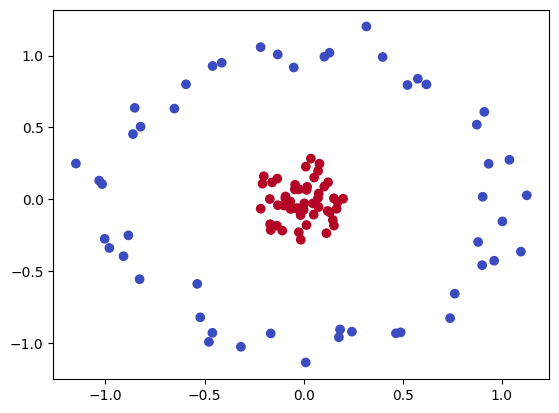

In [9]:
from matplotlib import cm
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=100, factor=0.1, noise=0.1)
plt.scatter(X[:,0], X[:,1], c=y,cmap=cm.coolwarm)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
model = SVC(kernel='rbf')
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test,y_pred))
from sklearn.metrics import accuracy_score



              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [11]:
print(accuracy_score(y_test,y_pred))

1.0


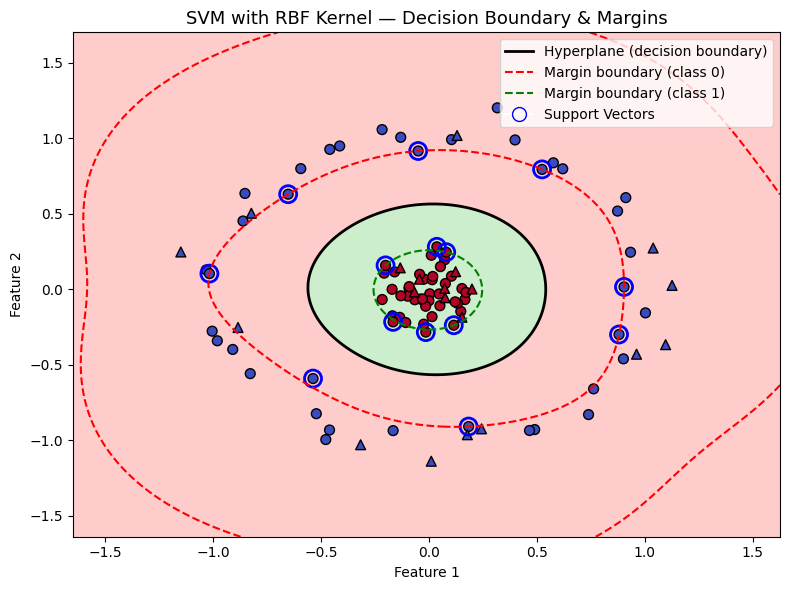

Number of support vectors: 14


In [12]:

# Train SVM with RBF kernel (suitable for non-linear circles data)
model_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
model_rbf.fit(X_train, y_train)

# Create a mesh grid to plot decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Get decision function values
Z = model_rbf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot decision boundary and margins
ax.contourf(xx, yy, Z, levels=[-1e5, 0, 1e5],
            alpha=0.2, colors=['#FF0000', '#00AA00'])
ax.contour(xx, yy, Z, levels=[-1, 0, 1],
           colors=['red', 'black', 'green'],
           linestyles=['--', '-', '--'], linewidths=[1.5, 2, 1.5])

# Plot training points
scatter = ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
                     cmap=cm.coolwarm, edgecolors='k', s=50, label='Train')
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test,
           cmap=cm.coolwarm, edgecolors='k', s=50, marker='^', label='Test')

# Highlight support vectors
ax.scatter(model_rbf.support_vectors_[:, 0],
           model_rbf.support_vectors_[:, 1],
           s=150, facecolors='none', edgecolors='blue',
           linewidths=2, label='Support Vectors')

# Labels and legend
ax.set_title('SVM with RBF Kernel — Decision Boundary & Margins', fontsize=13)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', lw=2, label='Hyperplane (decision boundary)'),
    Line2D([0], [0], color='red',   lw=1.5, linestyle='--', label='Margin boundary (class 0)'),
    Line2D([0], [0], color='green', lw=1.5, linestyle='--', label='Margin boundary (class 1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor='blue', markersize=10, label='Support Vectors'),
]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()
print(f"Number of support vectors: {model_rbf.support_vectors_.shape[0]}")
